# Forward-Looking Macro-Regime Portfolio Backtest


## Strategy Overview

Notebook 6 implemented a reactive regime-switching backtest: the portfolio changed only after a regime had already been identified from observed market data. The goal of this notebook is to test whether the macro model from Notebook 7 can move the allocation one step further by making it **forward-looking**.

Using the best machine learning model from Notebook 7, we begin each rebalance period with a set of predicted probabilities for the next month's regime:

- `P(Bull)`
- `P(Neutral)`
- `P(Crisis)`

Those probabilities are then used to form **probability-weighted expected returns and covariance matrices**, which become the inputs to the portfolio optimization problem for the coming month. The important question is empirical: do these macro probabilities improve the portfolio, or does the reactive HMM signal remain more useful once transaction timing and realized returns are considered?


## Load Predictions, Returns, and Regime Data


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

project_root = Path("..").resolve()
results_dir = project_root / "results"
processed_dir = project_root / "data" / "processed"


In [2]:
# Load daily returns and convert to monthly simple returns

daily_returns = pd.read_csv(processed_dir / "asset_returns.csv", index_col=0, parse_dates=True).sort_index()
assets = list(daily_returns.columns)

monthly_returns = np.exp(daily_returns[assets].resample("ME").sum()) - 1
monthly_returns.head()


,EFA,GLD,SPY,TLT,VNQ
Date,,,,,
2010-01-31,-0.074917,-0.034973,-0.052413,0.027837,-0.051179
2010-02-28,0.002668,0.032748,0.031194,-0.003424,0.055831
2010-03-31,0.063854,-0.004386,0.060880,-0.020574,0.101868
2010-04-30,-0.028046,0.058834,0.015470,0.033218,0.071502
2010-05-31,-0.111928,0.030513,-0.079455,0.051085,-0.053346


In [3]:
# Load macro-model outputs and HMM targets

with open(results_dir / "macro_regime_model_metadata.json") as f:
    macro_metadata = json.load(f)

best_model_name = macro_metadata["best_model"]
regime_order = macro_metadata["regime_order"]

macro_predictions = pd.read_csv(
    results_dir / "macro_regime_model_predictions.csv",
    parse_dates=["decision_month", "decision_date", "holding_month"],
)
macro_predictions = macro_predictions.loc[macro_predictions["model"] == best_model_name].copy()
macro_predictions = macro_predictions.sort_values("holding_month")

monthly_targets = pd.read_csv(
    results_dir / "monthly_hmm_regime_targets.csv",
    parse_dates=["decision_date", "decision_month", "holding_month"],
)
monthly_targets = monthly_targets.sort_values("holding_month")

macro_predictions.head()


,decision_month,decision_date,holding_month,current_regime,actual_next_regime,model,predicted_regime,p_Bull,p_Neutral,p_Crisis
2,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Random_Forest,Bull,0.640785,0.355774,0.003441
7,2015-03-31,2015-03-31,2015-04-30,Bull,Bull,Random_Forest,Bull,0.566021,0.432167,0.001811
12,2015-04-30,2015-04-30,2015-05-31,Bull,Bull,Random_Forest,Bull,0.568653,0.431347,0.000000
17,2015-05-31,2015-05-31,2015-06-30,Bull,Bull,Random_Forest,Bull,0.779554,0.218626,0.001820
22,2015-06-30,2015-06-30,2015-07-31,Bull,Bull,Random_Forest,Bull,0.728448,0.164792,0.106761


In [4]:
# Sanity checks for Notebook 7 handoff

prob_cols = [f"p_{regime}" for regime in regime_order]
probability_sums = macro_predictions[prob_cols].sum(axis=1)

handoff_checks = pd.Series({
    "best_model_predictions_present": not macro_predictions.empty,
    "probability_columns_present": set(prob_cols).issubset(macro_predictions.columns),
    "probabilities_sum_to_one": np.allclose(probability_sums, 1.0),
    "no_missing_probabilities": not macro_predictions[prob_cols].isna().any().any(),
    "holding_months_available": macro_predictions["holding_month"].isin(monthly_returns.index).any(),
    "one_prediction_per_holding_month": not macro_predictions["holding_month"].duplicated().any(),
}, name="passed")

assert handoff_checks.all(), handoff_checks[handoff_checks == False]
display(handoff_checks)


best_model_predictions_present      True
probability_columns_present         True
probabilities_sum_to_one            True
no_missing_probabilities            True
holding_months_available            True
one_prediction_per_holding_month    True
Name: passed, dtype: bool

In [5]:
# Load full-sample regime outputs from Notebook 5 for reference

regime_mean_returns = pd.read_csv(results_dir / "regime_mean_returns.csv", index_col=0)
regime_covariances = {
    "Bull": pd.read_csv(results_dir / "covariance_bull.csv", index_col=0),
    "Neutral": pd.read_csv(results_dir / "covariance_neutral.csv", index_col=0),
    "Crisis": pd.read_csv(results_dir / "covariance_crisis.csv", index_col=0),
}

regime_mean_returns = regime_mean_returns.reindex(columns=assets)
regime_covariances = {
    regime: cov.reindex(index=assets, columns=assets)
    for regime, cov in regime_covariances.items()
}

regime_mean_returns


,EFA,GLD,SPY,TLT,VNQ
regime_label,,,,,
Bull,0.130499,0.068708,0.216964,-0.000892,0.128640
Crisis,-0.460432,0.714756,-0.214499,0.408082,-0.448092
Neutral,-0.036143,0.096451,-0.040964,0.063110,0.033138


## Portfolio Math and Optimization Functions


In [6]:
# Portfolio helpers

def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)


def portfolio_volatility(weights, cov_matrix):
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    return np.sqrt(max(variance, 0.0))


def portfolio_turnover(weights, previous_weights):
    return np.abs(weights - previous_weights).sum()


def estimate_full_sample_moments(train_returns, annualize=True):
    mu = train_returns.mean().values
    cov = train_returns.cov().values

    if annualize:
        mu = mu * 252
        cov = cov * 252

    return mu, cov


def estimate_regime_specific_moments(train_returns, labeled_states, assets, annualize=True):
    merged = train_returns[assets].join(labeled_states[["current_regime"]], how="inner")
    regime_moments = {}

    for regime in regime_order:
        subset = merged.loc[merged["current_regime"] == regime, assets]

        if len(subset) < 2:
            regime_moments[regime] = {"mu": None, "cov": None, "count": len(subset)}
            continue

        mu = subset.mean().values
        cov = subset.cov().values

        if annualize:
            mu = mu * 252
            cov = cov * 252

        regime_moments[regime] = {"mu": mu, "cov": cov, "count": len(subset)}

    return regime_moments


def optimize_max_sharpe(mean_returns, cov_matrix, rf=0.0):
    mean_returns = np.nan_to_num(np.asarray(mean_returns, dtype=float), nan=0.0)
    cov_matrix = np.nan_to_num(np.asarray(cov_matrix, dtype=float), nan=0.0)
    cov_matrix = (cov_matrix + cov_matrix.T) / 2
    n_assets = len(mean_returns)
    cov_matrix = cov_matrix + np.eye(n_assets) * 1e-8
    init_weights = np.repeat(1 / n_assets, n_assets)
    bounds = [(0.0, 1.0)] * n_assets
    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)

    def objective(weights):
        port_return = portfolio_return(weights, mean_returns)
        port_vol = portfolio_volatility(weights, cov_matrix)
        if port_vol <= 0:
            return 1e6
        return -((port_return - rf) / port_vol)

    result = minimize(objective, init_weights, method="SLSQP", bounds=bounds, constraints=constraints)

    weights = result.x if result.success else init_weights
    weights = np.clip(weights, 0.0, 1.0)
    weights = weights / weights.sum() if weights.sum() > 0 else init_weights

    return {
        "weights": weights,
        "success": result.success,
        "message": result.message,
    }


def blend_regime_moments(probabilities, regime_moments, assets, min_observations=0):
    mu_mix = np.zeros(len(assets))
    cov_mix = np.zeros((len(assets), len(assets)))
    used_probability = 0.0

    for regime, probability in probabilities.items():
        info = regime_moments[regime]
        if info["mu"] is None or info["cov"] is None or info["count"] < min_observations:
            continue
        mu_mix += probability * info["mu"]
        cov_mix += probability * info["cov"]
        used_probability += probability

    if used_probability <= 0:
        return None, None, used_probability

    mu_mix /= used_probability
    cov_mix /= used_probability
    return mu_mix, cov_mix, used_probability


The forward-looking portfolio is constructed in two steps. First, the machine learning model generates a probability distribution over the next regime. Second, those probabilities are used to blend regime-specific moments:

$$
\mu_{t+1}^{mix} = \sum_k p_{k,t+1} \mu_k
$$

$$
\Sigma_{t+1}^{mix} = \sum_k p_{k,t+1} \Sigma_k
$$

The optimizer then solves for the long-only maximum-Sharpe portfolio using these blended inputs. Regimes with too few historical observations in the expanding window are excluded from the blend and the remaining probability mass is renormalized. This keeps early low-sample Crisis estimates from dominating the allocation.

Mechanically, the expected behavior is straightforward: when the macro model assigns more probability to Crisis, the blended moments should become more defensive and the optimizer should move toward assets that historically performed better in Crisis or Neutral states. The results section checks whether that behavior actually improves realized performance.


## Walk-Forward Backtest Construction


In [7]:
# Build a daily regime history for expanding-window moment estimation

daily_labeled_states = pd.read_csv(results_dir / "market_regimes.csv", parse_dates=["Date"])
daily_labeled_states = daily_labeled_states.rename(columns={"Date": "decision_date", "regime_label": "current_regime"})
daily_labeled_states = daily_labeled_states.set_index("decision_date").sort_index()

daily_labeled_states.head()


,regime,current_regime
decision_date,,
2010-02-02,2,Neutral
2010-02-03,2,Neutral
2010-02-04,2,Neutral
2010-02-05,2,Neutral
2010-02-08,2,Neutral


In [8]:
# Walk-forward backtest with equal-weight, static MV, reactive HMM, and macro-forward strategies

min_regime_obs = 40
backtest_rows = []

previous_weights = {
    "Equal_Weight": None,
    "Static_MV": None,
    "Reactive_HMM": None,
    "Macro_Forward": None,
}

for _, row in macro_predictions.iterrows():
    decision_date = row["decision_date"]
    decision_month = row["decision_month"]
    holding_month = row["holding_month"]

    if holding_month not in monthly_returns.index:
        continue

    train_daily_returns = daily_returns.loc[:decision_date, assets].copy()
    train_labeled_states = daily_labeled_states.loc[:decision_date].copy()
    realized_next_month = monthly_returns.loc[holding_month, assets].values.astype(float)

    full_mu, full_cov = estimate_full_sample_moments(train_daily_returns, annualize=True)
    regime_moments = estimate_regime_specific_moments(train_daily_returns, train_labeled_states, assets, annualize=True)

    equal_weight_weights = np.repeat(1 / len(assets), len(assets))

    static_result = optimize_max_sharpe(full_mu, full_cov, rf=0.0)
    static_weights = static_result["weights"]

    current_regime = row["current_regime"]
    current_regime_info = regime_moments[current_regime]

    if current_regime_info["mu"] is None or current_regime_info["cov"] is None or current_regime_info["count"] < min_regime_obs:
        reactive_weights = static_weights.copy()
        reactive_fallback = True
    else:
        reactive_result = optimize_max_sharpe(current_regime_info["mu"], current_regime_info["cov"], rf=0.0)
        reactive_weights = reactive_result["weights"]
        reactive_fallback = not reactive_result["success"]
        if reactive_fallback:
            reactive_weights = static_weights.copy()

    predicted_probabilities = {regime: row[f"p_{regime}"] for regime in regime_order}
    mixed_mu, mixed_cov, macro_used_probability = blend_regime_moments(
        predicted_probabilities,
        regime_moments,
        assets,
        min_observations=min_regime_obs,
    )

    if mixed_mu is None or mixed_cov is None:
        macro_weights = static_weights.copy()
        macro_fallback = True
    else:
        macro_result = optimize_max_sharpe(mixed_mu, mixed_cov, rf=0.0)
        macro_weights = macro_result["weights"]
        macro_fallback = not macro_result["success"]
        if macro_fallback:
            macro_weights = static_weights.copy()

    strategy_weights = {
        "Equal_Weight": equal_weight_weights,
        "Static_MV": static_weights,
        "Reactive_HMM": reactive_weights,
        "Macro_Forward": macro_weights,
    }

    strategy_returns = {name: weights @ realized_next_month for name, weights in strategy_weights.items()}

    strategy_turnover = {}
    for name, weights in strategy_weights.items():
        prev = previous_weights[name]
        strategy_turnover[name] = np.nan if prev is None else portfolio_turnover(weights, prev)
        previous_weights[name] = weights.copy()

    backtest_rows.append({
        "decision_date": decision_date,
        "decision_month": decision_month,
        "holding_month": holding_month,
        "current_regime": current_regime,
        "actual_next_regime": row["actual_next_regime"],
        **{f"p_{regime}": row[f"p_{regime}"] for regime in regime_order},
        "equal_weight_return": strategy_returns["Equal_Weight"],
        "static_mv_return": strategy_returns["Static_MV"],
        "reactive_hmm_return": strategy_returns["Reactive_HMM"],
        "macro_forward_return": strategy_returns["Macro_Forward"],
        "equal_weight_turnover": strategy_turnover["Equal_Weight"],
        "static_mv_turnover": strategy_turnover["Static_MV"],
        "reactive_hmm_turnover": strategy_turnover["Reactive_HMM"],
        "macro_forward_turnover": strategy_turnover["Macro_Forward"],
        "reactive_fallback": reactive_fallback,
        "macro_fallback": macro_fallback,
        "macro_used_probability": macro_used_probability,
        **{f"weight_equal_{asset}": equal_weight_weights[i] for i, asset in enumerate(assets)},
        **{f"weight_static_{asset}": static_weights[i] for i, asset in enumerate(assets)},
        **{f"weight_reactive_{asset}": reactive_weights[i] for i, asset in enumerate(assets)},
        **{f"weight_macro_{asset}": macro_weights[i] for i, asset in enumerate(assets)},
    })

backtest_results = pd.DataFrame(backtest_rows)
backtest_results.head()


,decision_date,decision_month,holding_month,current_regime,actual_next_regime,p_Bull,p_Neutral,p_Crisis,equal_weight_return,static_mv_return,reactive_hmm_return,macro_forward_return,equal_weight_turnover,static_mv_turnover,reactive_hmm_turnover,macro_forward_turnover,reactive_fallback,macro_fallback,macro_used_probability,weight_equal_EFA,weight_equal_GLD,weight_equal_SPY,weight_equal_TLT,weight_equal_VNQ,weight_static_EFA,weight_static_GLD,weight_static_SPY,weight_static_TLT,weight_static_VNQ,weight_reactive_EFA,weight_reactive_GLD,weight_reactive_SPY,weight_reactive_TLT,weight_reactive_VNQ,weight_macro_EFA,weight_macro_GLD,weight_macro_SPY,weight_macro_TLT,weight_macro_VNQ
0,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,0.640785,0.355774,0.003441,-0.004655,-0.002635,-0.009053,-0.002364,NaN,NaN,NaN,NaN,False,False,0.996559,0.2,0.2,0.2,0.2,0.2,1.081178e-15,7.279825e-17,0.509129,0.490871,5.627841e-17,6.728585e-16,2.967363e-16,0.750157,0.249843,7.255457e-16,1.031441e-16,2.605476e-16,0.498946,0.501054,3.813412e-17
1,2015-03-31,2015-03-31,2015-04-30,Bull,Bull,0.566021,0.432167,0.001811,-0.009620,-0.011856,-0.000890,-0.013640,0.0,0.002252,0.013191,0.062845,False,False,0.998189,0.2,0.2,0.2,0.2,0.2,7.002383e-17,1.359233e-16,0.508003,0.491997,4.081908e-17,0.000000e+00,9.579123e-18,0.756752,0.243248,0.000000e+00,1.960991e-16,3.470962e-16,0.467523,0.532477,0.000000e+00
2,2015-04-30,2015-04-30,2015-05-31,Bull,Bull,0.568653,0.431347,0.000000,-0.001277,-0.004892,0.004546,-0.006528,0.0,0.013625,0.032136,0.005141,False,False,1.000000,0.2,0.2,0.2,0.2,0.2,6.638956e-16,0.000000e+00,0.514815,0.485185,1.079728e-16,1.037302e-15,0.000000e+00,0.772820,0.227180,1.503776e-16,6.887032e-17,9.049158e-17,0.470094,0.529906,0.000000e+00
3,2015-05-31,2015-05-31,2015-06-30,Bull,Bull,0.779554,0.218626,0.001820,-0.030813,-0.030061,-0.024580,-0.028879,0.0,0.014941,0.036168,0.220291,False,False,0.998180,0.2,0.2,0.2,0.2,0.2,2.645300e-15,0.000000e+00,0.522285,0.477715,5.889386e-16,2.052661e-16,0.000000e+00,0.790904,0.209096,3.691635e-16,2.449869e-16,1.095519e-15,0.580240,0.419760,0.000000e+00
4,2015-06-30,2015-06-30,2015-07-31,Bull,Bull,0.728448,0.164792,0.106761,0.015973,0.033352,0.026890,0.031407,0.0,0.014266,0.042049,0.068433,False,False,0.893239,0.2,0.2,0.2,0.2,0.2,8.842651e-16,2.030598e-16,0.529418,0.470582,1.044276e-17,1.936846e-16,2.871746e-17,0.811928,0.188072,0.000000e+00,0.000000e+00,0.000000e+00,0.614456,0.385544,0.000000e+00


## Results

The strategy comparison evaluates four monthly-rebalanced portfolios over the same walk-forward period. `Equal_Weight` is the simple diversification baseline, `Static_MV` uses expanding-window moments without regimes, `Reactive_HMM` uses the currently observed HMM regime, and `Macro_Forward` uses the predicted next-month regime probabilities from Notebook 7.


In [9]:
# Sanity checks for backtest construction

return_cols = [
    "equal_weight_return",
    "static_mv_return",
    "reactive_hmm_return",
    "macro_forward_return",
]
weight_prefixes = ["weight_equal_", "weight_static_", "weight_reactive_", "weight_macro_"]

weight_sum_checks = {}
for prefix in weight_prefixes:
    cols = [f"{prefix}{asset}" for asset in assets]
    weight_sum_checks[prefix.rstrip("_")] = np.allclose(backtest_results[cols].sum(axis=1), 1.0)

backtest_checks = pd.Series({
    "backtest_rows_present": not backtest_results.empty,
    "no_missing_strategy_returns": not backtest_results[return_cols].isna().any().any(),
    "macro_blend_used_positive_probability": (backtest_results["macro_used_probability"] > 0).all(),
    **weight_sum_checks,
}, name="passed")

assert backtest_checks.all(), backtest_checks[backtest_checks == False]
display(backtest_checks)


backtest_rows_present                    True
no_missing_strategy_returns              True
macro_blend_used_positive_probability    True
weight_equal                             True
weight_static                            True
weight_reactive                          True
weight_macro                             True
Name: passed, dtype: bool

In [10]:
# Strategy return table

strategy_returns = backtest_results[[
    "holding_month",
    "equal_weight_return",
    "static_mv_return",
    "reactive_hmm_return",
    "macro_forward_return",
]].copy()

strategy_returns = strategy_returns.rename(columns={
    "equal_weight_return": "Equal_Weight",
    "static_mv_return": "Static_MV",
    "reactive_hmm_return": "Reactive_HMM",
    "macro_forward_return": "Macro_Forward",
}).set_index("holding_month")

strategy_returns.head()


,Equal_Weight,Static_MV,Reactive_HMM,Macro_Forward
holding_month,,,,
2015-03-31,-0.004655,-0.002635,-0.009053,-0.002364
2015-04-30,-0.009620,-0.011856,-0.000890,-0.013640
2015-05-31,-0.001277,-0.004892,0.004546,-0.006528
2015-06-30,-0.030813,-0.030061,-0.024580,-0.028879
2015-07-31,0.015973,0.033352,0.026890,0.031407


In [11]:
# Cumulative wealth

cumulative_returns = (1 + strategy_returns).cumprod()
cumulative_returns.head()


,Equal_Weight,Static_MV,Reactive_HMM,Macro_Forward
holding_month,,,,
2015-03-31,0.995345,0.997365,0.990947,0.997636
2015-04-30,0.985771,0.985540,0.990065,0.984028
2015-05-31,0.984512,0.980719,0.994566,0.977604
2015-06-30,0.954176,0.951237,0.970120,0.949372
2015-07-31,0.969417,0.982963,0.996207,0.979189


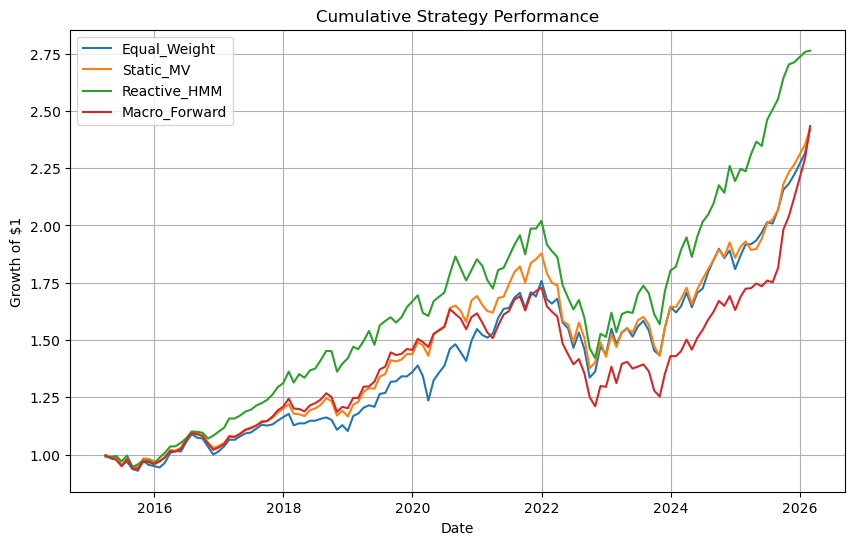

In [12]:
plt.figure(figsize=(10, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Performance statistics and drawdowns

def performance_stats(returns):
    ann_return = (1 + returns).prod() ** (12 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    cumulative = (1 + returns).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    max_dd = drawdown.min()

    return pd.Series({
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
    })

performance_table = strategy_returns.apply(performance_stats).T.sort_values("Sharpe Ratio", ascending=False)
performance_table


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Reactive_HMM,0.097540,0.106134,0.919032,-0.296556
Static_MV,0.084383,0.104736,0.805672,-0.266611
Macro_Forward,0.084859,0.105351,0.805483,-0.299578
Equal_Weight,0.084227,0.108892,0.773493,-0.239812


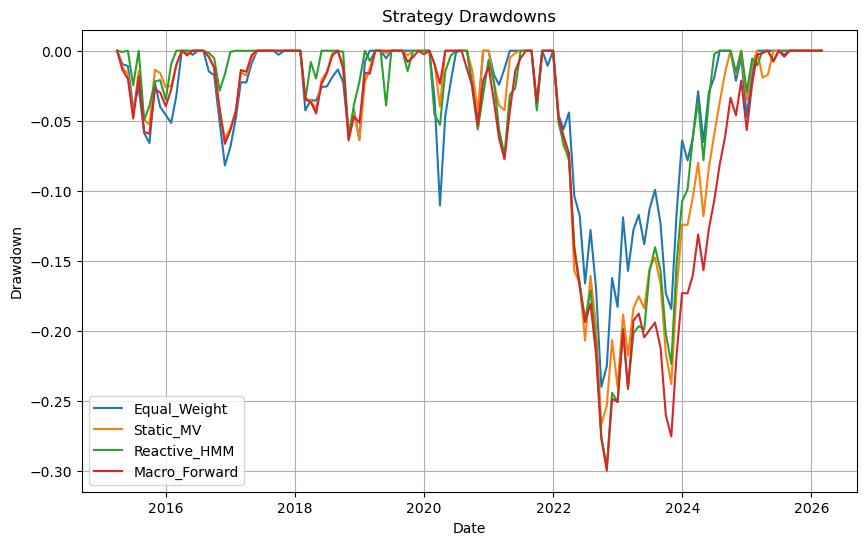

In [14]:
# Drawdown curves

drawdowns = cumulative_returns.divide(cumulative_returns.cummax()) - 1

plt.figure(figsize=(10, 6))
for col in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[col], label=col)

plt.title("Strategy Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()


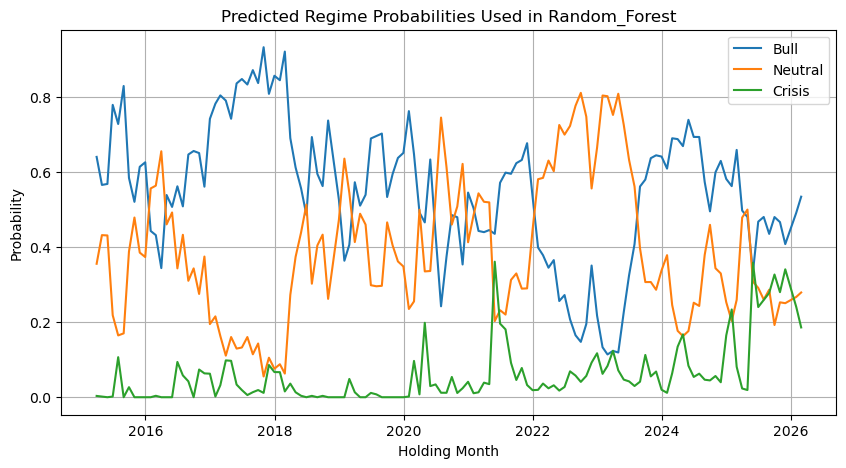

In [15]:
# Average predicted regime probabilities through time

plt.figure(figsize=(10, 5))
for regime in regime_order:
    plt.plot(backtest_results["holding_month"], backtest_results[f"p_{regime}"], label=regime)

plt.title(f"Predicted Regime Probabilities Used in {best_model_name}")
plt.xlabel("Holding Month")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()


## Diagnostics

The diagnostics below explain why the macro-forward strategy landed where it did in the performance table. They focus on regime probabilities, allocations, turnover, and performance conditional on realized regimes and predicted Crisis risk.

The central diagnostic question is whether the macro model produces useful defensive shifts. If the strategy raises GLD and TLT exposure when predicted Crisis risk rises, then the forecast is being translated into the intended portfolio behavior. The remaining question is whether those shifts are timed well enough to outperform the simpler reactive HMM benchmark.


In [16]:
# Predicted probability and realized regime diagnostics

probability_summary = backtest_results[prob_cols].agg(["mean", "median", "min", "max"]).T
probability_summary.columns = ["Mean", "Median", "Min", "Max"]

regime_transition_counts = pd.crosstab(
    backtest_results["current_regime"],
    backtest_results["actual_next_regime"],
    rownames=["Current Regime"],
    colnames=["Actual Next Regime"],
)

display(probability_summary)
display(regime_transition_counts)


,Mean,Median,Min,Max
p_Bull,0.549444,0.562914,0.114089,0.933176
p_Neutral,0.389317,0.362062,0.055279,0.811507
p_Crisis,0.061240,0.034189,0.000000,0.361384


Actual Next Regime,Bull,Crisis,Neutral
Current Regime,,,
Bull,74,0,12
Crisis,1,1,1
Neutral,11,2,29


,Equal_Weight,Static_MV,Reactive_HMM,Macro_Forward
EFA,0.2,1.764825e-16,3.176527e-16,4.575541e-16
GLD,0.2,3.869023e-02,7.628360e-02,1.500155e-01
SPY,0.2,5.255613e-01,5.360370e-01,3.618273e-01
TLT,0.2,4.357485e-01,3.122781e-01,4.569290e-01
VNQ,0.2,8.794399e-17,7.540131e-02,3.122826e-02


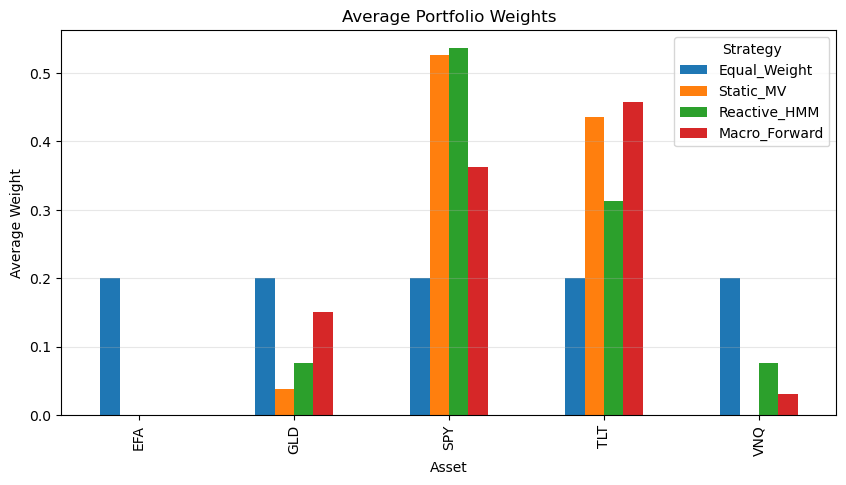

In [17]:
# Average portfolio weights by strategy

weight_summary = pd.DataFrame({
    "Equal_Weight": [backtest_results[f"weight_equal_{asset}"].mean() for asset in assets],
    "Static_MV": [backtest_results[f"weight_static_{asset}"].mean() for asset in assets],
    "Reactive_HMM": [backtest_results[f"weight_reactive_{asset}"].mean() for asset in assets],
    "Macro_Forward": [backtest_results[f"weight_macro_{asset}"].mean() for asset in assets],
}, index=assets)

display(weight_summary)

weight_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Average Portfolio Weights")
plt.xlabel("Asset")
plt.ylabel("Average Weight")
plt.legend(title="Strategy")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [18]:
# Turnover and fallback diagnostics

turnover_cols = [
    "equal_weight_turnover",
    "static_mv_turnover",
    "reactive_hmm_turnover",
    "macro_forward_turnover",
]

turnover_summary = pd.DataFrame({
    "Average Turnover": backtest_results[turnover_cols].mean(),
    "Median Turnover": backtest_results[turnover_cols].median(),
}).rename(index={
    "equal_weight_turnover": "Equal_Weight",
    "static_mv_turnover": "Static_MV",
    "reactive_hmm_turnover": "Reactive_HMM",
    "macro_forward_turnover": "Macro_Forward",
})

fallback_summary = pd.Series({
    "Reactive_HMM fallback months": int(backtest_results["reactive_fallback"].sum()),
    "Macro_Forward fallback months": int(backtest_results["macro_fallback"].sum()),
    "Average macro probability used": backtest_results["macro_used_probability"].mean(),
    "Minimum macro probability used": backtest_results["macro_used_probability"].min(),
}, name="Value")

display(turnover_summary)
display(fallback_summary)


,Average Turnover,Median Turnover
Equal_Weight,0.000000,0.000000
Static_MV,0.017517,0.014039
Reactive_HMM,0.339143,0.031822
Macro_Forward,0.174494,0.128975


Reactive_HMM fallback months      0.000000
Macro_Forward fallback months     0.000000
Average macro probability used    0.989663
Minimum macro probability used    0.893239
Name: Value, dtype: float64

In [19]:
# Strategy performance by realized next-month regime

strategy_return_cols = {
    "equal_weight_return": "Equal_Weight",
    "static_mv_return": "Static_MV",
    "reactive_hmm_return": "Reactive_HMM",
    "macro_forward_return": "Macro_Forward",
}

performance_by_actual_regime = (
    backtest_results
    .groupby("actual_next_regime")[list(strategy_return_cols)]
    .agg(["count", "mean", "std"])
    .rename(columns=strategy_return_cols, level=0)
)

display(performance_by_actual_regime)


Equal_Weight                     Static_MV                     Reactive_HMM                      \
                          count      mean       std     count      mean       std        count      mean       std   
actual_next_regime                                                                                                   
Bull                         86  0.011278  0.025128        86  0.012851  0.024456           86  0.014602  0.025274   
Crisis                        3  0.000385  0.076147         3  0.012198  0.049174            3  0.018712  0.024371   
Neutral                      42 -0.000503  0.037975        42 -0.004640  0.036443           42 -0.005497  0.036563   

                   Macro_Forward                      
                           count      mean       std  
actual_next_regime                                    
Bull                          86  0.012637  0.026512  
Crisis                         3  0.012331  0.026732  
Neutral                       42 -0.004089  0.035301

In [20]:
# Strategy behavior by predicted Crisis probability quartile

crisis_diagnostic = backtest_results.copy()
crisis_diagnostic["crisis_probability_quartile"] = pd.qcut(
    crisis_diagnostic["p_Crisis"].rank(method="first"),
    4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"],
)

crisis_probability_performance = (
    crisis_diagnostic
    .groupby("crisis_probability_quartile", observed=True)
    [["p_Crisis", *strategy_return_cols.keys()]]
    .mean()
    .rename(columns=strategy_return_cols)
)

macro_weights_by_crisis_quartile = (
    crisis_diagnostic
    .groupby("crisis_probability_quartile", observed=True)
    [[f"weight_macro_{asset}" for asset in assets]]
    .mean()
    .rename(columns={f"weight_macro_{asset}": asset for asset in assets})
)

display(crisis_probability_performance)
display(macro_weights_by_crisis_quartile)


,p_Crisis,Equal_Weight,Static_MV,Reactive_HMM,Macro_Forward
crisis_probability_quartile,,,,,
Q1 Low,0.000955,0.005138,0.005208,0.006194,0.005127
Q2,0.019586,0.001771,0.001001,0.005116,0.000793
Q3,0.052462,0.007842,0.007621,0.010021,0.003402
Q4 High,0.171690,0.014273,0.015095,0.011731,0.019629


,EFA,GLD,SPY,TLT,VNQ
crisis_probability_quartile,,,,,
Q1 Low,1.240126e-16,0.001537,0.444836,0.521166,0.032461
Q2,1.091455e-16,0.075192,0.401166,0.473308,0.050334
Q3,1.375585e-15,0.180829,0.330706,0.449370,0.039095
Q4 High,2.492923e-16,0.343438,0.269658,0.383643,0.003261


In [21]:
# Macro-forward relative performance diagnostics

macro_relative_returns = pd.DataFrame({
    "Macro minus Equal_Weight": strategy_returns["Macro_Forward"] - strategy_returns["Equal_Weight"],
    "Macro minus Static_MV": strategy_returns["Macro_Forward"] - strategy_returns["Static_MV"],
    "Macro minus Reactive_HMM": strategy_returns["Macro_Forward"] - strategy_returns["Reactive_HMM"],
})

macro_relative_summary = macro_relative_returns.agg(["mean", "median", "min", "max"])

display(macro_relative_summary)
display(macro_relative_returns.tail(12))


,Macro minus Equal_Weight,Macro minus Static_MV,Macro minus Reactive_HMM
mean,0.000015,0.000039,-0.000985
median,-0.001462,-0.000364,-0.001601
min,-0.051320,-0.050135,-0.054506
max,0.065409,0.042678,0.064692


,Macro minus Equal_Weight,Macro minus Static_MV,Macro minus Reactive_HMM
holding_month,,,
2025-02-28,-0.005215,0.008578,0.025633
2025-03-31,0.000815,0.020464,-0.032303
2025-04-30,0.003137,0.009912,-0.011578
2025-05-31,-0.025134,-0.031103,0.000561
2025-06-30,-0.008011,-0.020086,-0.033787
2025-07-31,-0.001391,-0.012176,-0.022936
2025-08-31,0.005520,0.014239,0.017640
2025-09-30,0.050172,0.038501,0.056585
2025-10-31,0.017295,0.005283,0.006627


### Interpretation

The forward-looking macro strategy behaves in the intended direction, but it does not dominate the reactive HMM benchmark. `Reactive_HMM` has the strongest overall result, with the highest annual return and Sharpe ratio. `Macro_Forward` slightly improves on `Equal_Weight` and is nearly tied with `Static_MV`, but it has a larger maximum drawdown than both.

The diagnostics show that the macro signal is economically sensible. Average predicted probabilities are tilted toward Bull and Neutral regimes, with Crisis receiving a smaller but time-varying probability. As predicted Crisis probability rises, the macro portfolio shifts away from SPY and toward GLD and TLT. That means the probability forecast is being translated into a genuine defensive allocation rather than being ignored by the optimizer.

The limitation is timing and opportunity cost. Several high-Crisis-probability months were still realized Bull months, so the more defensive macro allocation sometimes gave up equity upside. The reactive HMM strategy, by staying tied to the observed market regime, maintained higher average SPY exposure and captured more of those Bull-period gains.

Turnover also helps explain the result. `Macro_Forward` trades less than `Reactive_HMM`, but more than `Static_MV`. This gives it a smoother probability-weighted profile, but the smoother signal does not deliver enough performance improvement to overtake the reactive regime strategy in this sample.

The main conclusion is therefore nuanced: macro regime probabilities are useful as a risk signal and create plausible defensive shifts, but the current Random Forest probability stream is not strong enough to beat the reactive HMM allocation. The macro layer adds interpretability and forward-looking behavior, but not a clear performance edge in this version.


In [22]:
# Save backtest outputs

backtest_results.to_csv(results_dir / "macro_forward_backtest_results.csv", index=False)
strategy_returns.to_csv(results_dir / "macro_forward_strategy_returns.csv")
cumulative_returns.to_csv(results_dir / "macro_forward_cumulative_returns.csv")
drawdowns.to_csv(results_dir / "macro_forward_drawdowns.csv")
performance_table.to_csv(results_dir / "macro_forward_performance_summary.csv")

metadata = {
    "best_macro_model": best_model_name,
    "allocation_method": "probability_weighted_regime_moments",
    "optimizer": "long_only_max_sharpe",
    "regime_order": regime_order,
    "min_regime_observations": min_regime_obs,
    "min_macro_blend_observations": min_regime_obs,
}

with open(results_dir / "macro_forward_backtest_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4, default=str)


## Summary and Next Steps

This notebook used predicted regime probabilities from the best macroeconomic classifier to build a **forward-looking regime-switching strategy**. At each rebalance date, regime-specific expected returns and covariance matrices were blended using the forecast probabilities, and the resulting mixed moments were fed into a long-only portfolio optimization problem.

The results provide a clear but mixed answer to the core project question. Macroeconomic information does help create forward-looking regime-aware allocations: the macro strategy becomes more defensive when predicted Crisis risk rises, and it performs competitively with the static mean-variance benchmark. However, it does not outperform the reactive HMM strategy, which remains the strongest portfolio in this experiment.

The next research step would be to refine how macro probabilities are used rather than treating this first version as the final allocation rule. Possible extensions include probability calibration, blending macro forecasts with current-regime persistence, adding transaction costs or turnover penalties, and testing whether macro probabilities are better used for risk scaling than for both expected-return and covariance blending.
